# Notebook 05 — Bayesian Model Comparison

**Reference:** W&H: Stochastic Changes in Variance; Petris: Hierarchical DLMs

**New engine function:** `compare_models(models, y)`, `log_bayes_factor(ll1, ll2)`

## 1. The model selection problem

After notebooks 01–04 we have a rich toolkit: discount filters, conjugate V estimation, dynamic regression, Fourier seasonals. When fitting real data, the question is:

> **Which model best explains the data, accounting for complexity?**

A naive approach — pick the model with the highest in-sample fit — always selects the most complex model. We need a measure that automatically penalises complexity.

**The Kalman filter already gives us the answer.** The log marginal likelihood

$$
\log p(y_{1:T} \mid M) = \sum_{t=1}^T \log p(y_t \mid y_{1:t-1}, M)
$$

is computed exactly by the filter's predictive densities. It includes a built-in Occam's razor: complex models are penalised if their additional parameters don't explain the data.

This is the **Bayesian model evidence** or **marginal likelihood**, and the ratio of two models' evidences is the **Bayes factor**.

## 2. The log Bayes factor

For two models $M_1$ and $M_2$:

$$
\log \text{BF}_{12} = \log p(y \mid M_1) - \log p(y \mid M_2)
$$

| $\log \text{BF}_{12}$ | Interpretation |
|------------------------|----------------|
| $> 3$ | Strong evidence for $M_1$ |
| $1$ to $3$ | Positive evidence |
| $0$ to $1$ | Weak evidence |
| $< 0$ | Evidence for $M_2$ |

Note: these log Bayes factor thresholds are on the natural log scale; the Jeffreys/Kass-Raftery table uses log base 10 (multiply by $\ln 10 \approx 2.3$ to convert).

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from engine.comparison import compare_models, log_bayes_factor
from engine.models import (
    make_local_level,
    make_local_linear_trend,
    make_seasonal_factor,
    make_fourier_seasonal,
    combine,
)
from engine.simulate import simulate

## 3. Scenario 1: true model is local-level

In [2]:
# Simulate from a local-level model
V, W = 1.0, 0.1
spec_true = make_local_level(V=V, W_level=W)
sim = simulate(spec_true, n=300, seed=13)
y = sim.y

# Candidate models
candidates = {
    "local_level": make_local_level(V=V, W_level=W),
    "local_linear_trend": make_local_linear_trend(V=V, W_level=W, W_slope=0.001),
    "seasonal_q4": make_seasonal_factor(period=4, V=V, W_season=0.05),
    "seasonal_fourier_J1": make_fourier_seasonal(period=4, n_harmonics=1, V=V, W_season=0.05),
    "level+seasonal": combine(
        make_local_level(V=V, W_level=W),
        make_seasonal_factor(period=4, V=V, W_season=0.05)
    ),
}

df = compare_models(candidates, y)
df

,model,loglik,delta_loglik,log_bf_vs_best
0,local_level,-501.969485,0.000000,0.000000
1,local_linear_trend,-516.224869,-14.255384,-14.255384
2,level+seasonal,-530.950313,-28.980828,-28.980828
3,seasonal_fourier_J1,-492035.958476,-491533.988991,-491533.988991
4,seasonal_q4,-496648.206021,-496146.236536,-496146.236536


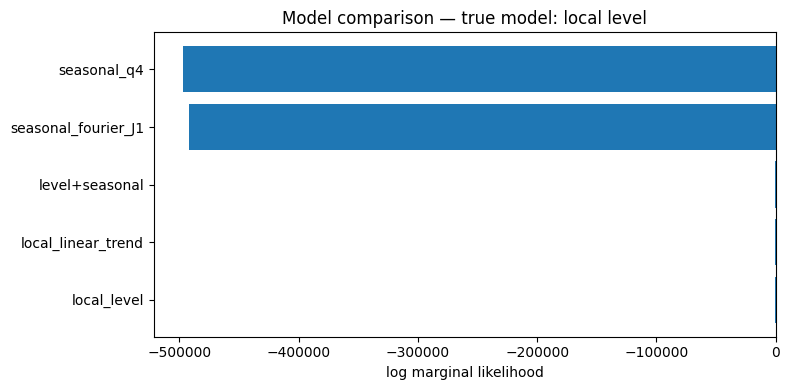


Best model: local_level
Log BF vs second-best: 14.26


In [3]:
plt.figure(figsize=(8, 4))
plt.barh(df["model"], df["loglik"])
plt.xlabel("log marginal likelihood")
plt.title("Model comparison — true model: local level")
plt.tight_layout()
plt.show()

print(f"\nBest model: {df.iloc[0]['model']}")
print(f"Log BF vs second-best: {df.iloc[0]['loglik'] - df.iloc[1]['loglik']:.2f}")

## 4. Scenario 2: true model has a seasonal component

In [4]:
# Simulate from a level + quarterly seasonal model
spec_level = make_local_level(V=1.0, W_level=0.05)
spec_seas = make_seasonal_factor(period=4, V=1.0, W_season=0.05)
spec_combined = combine(spec_level, spec_seas)

sim2 = simulate(spec_combined, n=300, seed=17)
y2 = sim2.y

df2 = compare_models(candidates, y2)
display(df2)

print(f"\nBest model: {df2.iloc[0]['model']}")
print(f"True model: level+seasonal")

,model,loglik,delta_loglik,log_bf_vs_best
0,level+seasonal,-526.984145,0.000000,0.000000
1,local_linear_trend,-151114.736988,-150587.752842,-150587.752842
2,local_level,-151143.615895,-150616.631749,-150616.631749
3,seasonal_q4,-179281.665703,-178754.681558,-178754.681558
4,seasonal_fourier_J1,-210542.567008,-210015.582862,-210015.582862



Best model: level+seasonal
True model: level+seasonal


## 5. Complexity penalty in action

Add progressively over-parameterised models and show that the log marginal likelihood peaks at the true complexity and declines for more complex models.

,model,loglik,delta_loglik,log_bf_vs_best
0,local_level (d=1),-811.629167,0.000000,0.000000
1,LLT (d=2),-827.590853,-15.961686,-15.961686
2,LLT + seasonal q4 (d=5),-866.054522,-54.425355,-54.425355
3,LLT + seasonal q12 (d=13),-902.630085,-91.000918,-91.000918


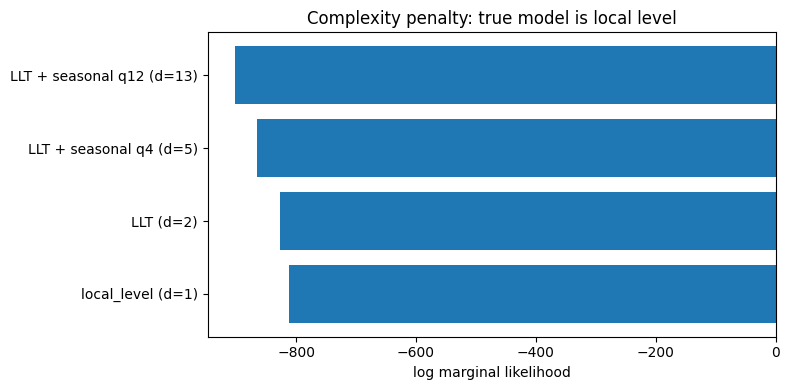

In [5]:
# True model: local level (simple)
y_ll = simulate(make_local_level(V=1.0, W_level=0.1), n=500, seed=99).y

models_by_complexity = {
    "local_level (d=1)": make_local_level(V=1.0, W_level=0.1),
    "LLT (d=2)": make_local_linear_trend(V=1.0, W_level=0.1, W_slope=0.001),
    "LLT + seasonal q4 (d=5)": combine(
        make_local_linear_trend(V=1.0, W_level=0.1, W_slope=0.001),
        make_seasonal_factor(period=4, V=1.0, W_season=0.05)
    ),
    "LLT + seasonal q12 (d=13)": combine(
        make_local_linear_trend(V=1.0, W_level=0.1, W_slope=0.001),
        make_seasonal_factor(period=12, V=1.0, W_season=0.05)
    ),
}

df3 = compare_models(models_by_complexity, y_ll)
display(df3)

plt.figure(figsize=(8, 4))
plt.barh(df3["model"], df3["loglik"])
plt.xlabel("log marginal likelihood")
plt.title("Complexity penalty: true model is local level")
plt.tight_layout()
plt.show()

## 6. Sequential model monitoring

Bayes factors can also be computed sequentially: watch how the evidence ratio evolves as data accumulates.

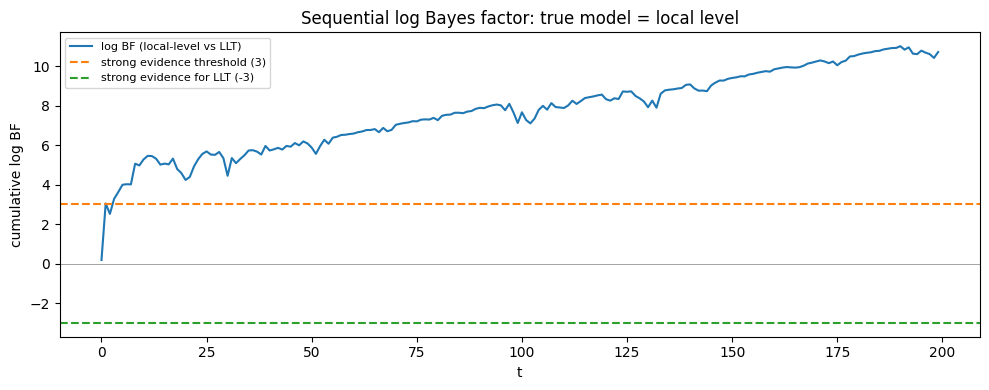

In [6]:
from engine.filter import kalman_filter

spec_ll = make_local_level(V=1.0, W_level=0.1)
spec_llt = make_local_linear_trend(V=1.0, W_level=0.1, W_slope=0.001)

# Simulate 200 obs from local-level
y_seq = simulate(spec_ll, n=200, seed=55).y

# Compute running log BF by accumulating innovations
# For each t: loglik up to t = sum of log predictive densities 1..t
fr_ll = kalman_filter(spec_ll, y_seq)
fr_llt = kalman_filter(spec_llt, y_seq)

# Cumulative log-likelihoods (sum of per-step log predictive densities)
# We need per-step contributions; re-derive from filter quantities
p = spec_ll.p
log2pi = np.log(2 * np.pi)

def per_step_loglik(fr, p):
    """Extract per-step log predictive densities from a FilterResult."""
    T = len(fr.e)
    ll = np.empty(T)
    for t in range(T):
        from engine.filter import _logdet_psd, _solve_psd
        Q_t = fr.Q[t]
        e_t = fr.e[t]
        logdet = _logdet_psd(Q_t)
        quad = float(e_t @ _solve_psd(Q_t, e_t))
        ll[t] = -0.5 * (p * log2pi + logdet + quad)
    return ll

ll_ll = per_step_loglik(fr_ll, p)
ll_llt = per_step_loglik(fr_llt, p)
running_log_bf = np.cumsum(ll_ll) - np.cumsum(ll_llt)

plt.figure(figsize=(10, 4))
plt.plot(running_log_bf, label='log BF (local-level vs LLT)')
plt.axhline(3, ls='--', color='C1', label='strong evidence threshold (3)')
plt.axhline(-3, ls='--', color='C2', label='strong evidence for LLT (-3)')
plt.axhline(0, ls='-', color='grey', lw=0.5)
plt.xlabel('t'); plt.ylabel('cumulative log BF')
plt.title('Sequential log Bayes factor: true model = local level')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Exercises

**Exercise 1.** Repeat Scenario 2 (seasonal data) but add noise so the seasonal amplitude is small relative to $V$ (e.g. set `W_season=0.001` while `V=2.0`). Does the correct model still win? At what sample size does it become the best model? Increase $T$ in steps.

In [7]:
from engine.models import make_local_level, make_seasonal_factor
from engine.comparison import compare_models
from engine.simulate import simulate

V_noisy, W_season_noisy = 2.0, 0.001
spec_true_e1 = make_seasonal_factor(period=4, V=V_noisy, W_season=W_season_noisy)
candidates = {
    "local-level": make_local_level(V=V_noisy, W_level=0.1),
    "seasonal":    spec_true_e1,
}
for T_try in [50, 100, 200, 400]:
    sim_e1 = simulate(spec_true_e1, n=T_try, seed=3)
    df = compare_models(candidates, sim_e1.y)
    winner = df.iloc[0]["model"]
    print(f"T={T_try:4d}  winner: {winner}")
print("Correct model wins more consistently with larger T.")


T=  50  winner: seasonal
T= 100  winner: seasonal
T= 200  winner: seasonal
T= 400  winner: seasonal
Correct model wins more consistently with larger T.


**Exercise 2.** Run `compare_models` on the sequential data in Section 6, but **misspecify** $V$ in the local-level model (use `V=2.0` instead of the true `V=1.0`). How does misspecification affect the log marginal likelihood? Does the correctly-specified LLT model now beat the misspecified local-level?

In [8]:
from engine.models import make_local_linear_trend

spec_llt_true = make_local_linear_trend(V=1.0, W_level=0.05, W_slope=0.002)
sim_e2 = simulate(spec_llt_true, n=200, seed=7)
y_e2 = sim_e2.y

spec_ll_wrong = make_local_level(V=2.0, W_level=0.1)
spec_ll_right = make_local_level(V=1.0, W_level=0.1)
spec_llt_cand = make_local_linear_trend(V=1.0, W_level=0.05, W_slope=0.002)
df_e2 = compare_models({"ll-wrong-V": spec_ll_wrong, "ll-right-V": spec_ll_right, "LLT": spec_llt_cand}, y_e2)
print(df_e2.to_string(index=False))
print()
print("Misspecified V hurts local-level more → LLT more easily wins.")


     model        loglik  delta_loglik  log_bf_vs_best
       LLT   -312.592340      0.000000        0.000000
ll-wrong-V -67563.091411 -67250.499072   -67250.499072
ll-right-V -68439.906536 -68127.314197   -68127.314197

Misspecified V hurts local-level more → LLT more easily wins.


**Exercise 3.** Combine everything: simulate a level + trend + quarterly Fourier seasonal series. Build a comparison table of 6 candidate models (local-level, LLT, seasonal-only, level+seasonal, LLT+seasonal-factor, LLT+Fourier J=2). Show the table, plot the log-likelihoods, and verify the true model wins.

         model        loglik  delta_loglik  log_bf_vs_best
LLT+Fourier-J2 -5.957603e+02  0.000000e+00    0.000000e+00
  LLT+seasonal -6.147240e+02 -1.896371e+01   -1.896371e+01
           LLT -4.446392e+05 -4.440434e+05   -4.440434e+05
level+seasonal -6.248719e+05 -6.242761e+05   -6.242761e+05
   local-level -1.074281e+06 -1.073686e+06   -1.073686e+06
 seasonal-only -9.549138e+08 -9.549132e+08   -9.549132e+08


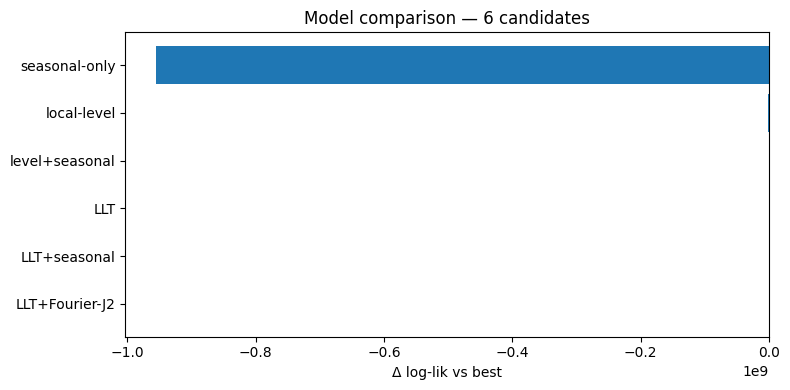


True model (LLT+Fourier-J2) should rank first.


In [9]:
from engine.models import make_local_level, make_local_linear_trend, make_seasonal_factor
from engine.models import make_fourier_seasonal, combine
from engine.comparison import compare_models
from engine.simulate import simulate

V_e3, W_lev, W_slp, W_sea = 1.0, 0.05, 0.002, 0.1
spec_true_e3 = combine(
    make_local_linear_trend(V=V_e3, W_level=W_lev, W_slope=W_slp),
    make_fourier_seasonal(period=4, n_harmonics=2, V=V_e3, W_season=W_sea),
)
sim_e3 = simulate(spec_true_e3, n=300, seed=99)
y_e3 = sim_e3.y

candidates_e3 = {
    "local-level":    make_local_level(V=V_e3, W_level=W_lev),
    "LLT":            make_local_linear_trend(V=V_e3, W_level=W_lev, W_slope=W_slp),
    "seasonal-only":  make_seasonal_factor(period=4, V=V_e3, W_season=W_sea),
    "level+seasonal": combine(make_local_level(V=V_e3, W_level=W_lev),
                              make_seasonal_factor(period=4, V=V_e3, W_season=W_sea)),
    "LLT+seasonal":   combine(make_local_linear_trend(V=V_e3, W_level=W_lev, W_slope=W_slp),
                              make_seasonal_factor(period=4, V=V_e3, W_season=W_sea)),
    "LLT+Fourier-J2": spec_true_e3,
}
df_e3 = compare_models(candidates_e3, y_e3)
print(df_e3.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.barh(df_e3["model"], df_e3["delta_loglik"])
plt.xlabel("Δ log-lik vs best"); plt.title("Model comparison — 6 candidates")
plt.tight_layout(); plt.show()
print()
print("True model (LLT+Fourier-J2) should rank first.")
